# OSM City POI Downloader

Download POIs for a city from OpenStreetMap and extract geolocation + attributes for downstream use.


In [1]:
# If needed, install osmnx and contextily in your environment.
# %pip install osmnx contextily
%pip install scipy


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import re
import random
import numpy as np
from shapely.geometry import Point
import pandas as pd
import geopandas as gpd
import osmnx as ox

ox.settings.log_console = True
ox.settings.use_cache = True


In [3]:
# City name can be any place string recognized by OSM/Nominatim.
city_name = "Beijing, China"

# Use Nominatim's top match by default. Set to None to use all results.
which_result = 1

# POI-related tags (set to True to fetch all values of that tag).
tags = {
    "amenity": True,
    "shop": True,
    "tourism": True,
    "leisure": True,
    "office": True,
    "craft": True,
    "man_made": True,
}


In [4]:
# Output paths for cached data.
out_dir = Path("data/osm")
out_dir.mkdir(parents=True, exist_ok=True)

# Derive a safe filename from the city name to avoid cache collisions.
city_slug = re.sub(r"[^a-z0-9]+", "_", city_name.lower()).strip("_")

csv_path = out_dir / f"poi_attributes_{city_slug}.csv"
geojson_path = out_dir / f"poi_features_{city_slug}.geojson"
boundary_path = out_dir / f"city_boundary_{city_slug}.geojson"

# If you change city_name, a new cache file will be used automatically.
if csv_path.exists():
    poi_df = pd.read_csv(csv_path)
    print(f"Loaded {len(poi_df)} POIs from {csv_path}")
else:
    # Query OSM features for the place.
    gdf = ox.features_from_place(city_name, tags)
    gdf = gdf.to_crs(epsg=4326)
    gdf = gdf.reset_index()

    # Normalize geometry to points for geolocation.
    geom = gdf.geometry
    point_geom = geom.apply(
        lambda g: g if g.geom_type == "Point" else g.representative_point()
    )
    gdf["lon"] = point_geom.x
    gdf["lat"] = point_geom.y

    # Pick useful columns if present.
    base_cols = [
        "element_type",
        "osmid",
        "name",
        "amenity",
        "shop",
        "tourism",
        "leisure",
        "office",
        "craft",
        "man_made",
        "building",
        "addr:city",
        "addr:street",
        "addr:housenumber",
    ]
    cols = [c for c in base_cols if c in gdf.columns]
    poi_df = gdf[cols + ["lat", "lon"]].copy()

    # Save outputs for downstream processing.
    poi_df.to_csv(csv_path, index=False)
    gdf.to_file(geojson_path, driver="GeoJSON")

    print(f"Saved {len(poi_df)} POIs to {csv_path}")

# City boundary (geofence).
city_gdf = ox.geocode_to_gdf(city_name, which_result=which_result).to_crs(epsg=4326)

# If multiple matches are returned, keep the largest polygon.
if len(city_gdf) > 1 and which_result is None:
    city_gdf_3857 = city_gdf.to_crs(epsg=3857)
    keep_idx = city_gdf_3857.area.idxmax()
    city_gdf = city_gdf.loc[[keep_idx]]

city_geom = city_gdf.geometry.iloc[0]
if not city_geom.is_valid:
    city_geom = city_geom.buffer(0)

city_gdf.to_file(boundary_path, driver="GeoJSON")
print(f"Saved city boundary to {boundary_path}")

# Filter POIs to inside the city boundary.
poi_df = poi_df.dropna(subset=["lat", "lon"]).copy()
poi_gdf = gpd.GeoDataFrame(
    poi_df,
    geometry=gpd.points_from_xy(poi_df["lon"], poi_df["lat"]),
    crs="EPSG:4326",
)
poi_gdf = poi_gdf[poi_gdf.within(city_geom)].copy()
poi_df_filtered = pd.DataFrame(poi_gdf.drop(columns="geometry"))
print(f"Filtered to {len(poi_df_filtered)} POIs inside boundary")

poi_df_filtered.head()


Loaded 60940 POIs from data/osm/poi_attributes_beijing_china.csv
Saved city boundary to data/osm/city_boundary_beijing_china.geojson
Filtered to 60900 POIs inside boundary


,name,amenity,shop,tourism,leisure,office,craft,man_made,building,addr:city,addr:street,addr:housenumber,lat,lon
0,Guxiang 20,NaN,NaN,hotel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.938208,116.397217
1,Under Renovation (used to be Bookworm),restaurant,books,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.931104,116.449759
2,荷花市场,NaN,NaN,attraction,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.932530,116.385748
3,NaN,toilets,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.980869,116.267504
4,北京古观象台,NaN,NaN,attraction,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.906180,116.428353


## Template-Based Question Generation (OSM)

Use OSM POIs to generate template-style questions without Google Maps.


In [5]:
# Build POI type field from OSM tags.
type_columns = ["amenity", "shop", "tourism", "leisure", "office", "craft", "man_made", "building"]

def first_non_null(row):
    for col in type_columns:
        val = row.get(col)
        if isinstance(val, str) and val.strip():
            return val
    return None

poi_df_filtered = poi_df_filtered.copy()
poi_df_filtered["poi_type"] = poi_df_filtered.apply(first_non_null, axis=1)
poi_df_filtered["poi_type"] = poi_df_filtered["poi_type"].fillna("poi")

def make_label(row):
    name = row.get("name")
    poi_type = row.get("poi_type")
    label = name if isinstance(name, str) and name.strip() else poi_type
    return f"{label} ({row['lat']:.4f}, {row['lon']:.4f})"

poi_df_filtered["location_label"] = poi_df_filtered.apply(make_label, axis=1)

location_dict = {
    row["location_label"]: {
        "location": [row["lat"], row["lon"]],
        "poi_type": row["poi_type"],
    }
    for _, row in poi_df_filtered.iterrows()
}
place_types = sorted({t for t in poi_df_filtered["poi_type"].dropna().tolist()})

question_templates = [
    "Find me a {place_type} along the way from {location_A} to {location_B}.",
    "Find me a {place_type} along the way from {location_A} to {location_B}, within {buffer_range}km of the route.",
    "Find me a {place_type} along the way from {location_A} to {location_B}, passing through {location_C}.",
]
question_weights = [0.5, 0.25, 0.25]
num_questions = 50

def generate_question(template, poi_types, loc_dict, used_pairs):
    loc_keys = list(loc_dict)
    if len(loc_keys) < 2:
        raise ValueError('Not enough locations to sample from.')

    place_type = random.choice(poi_types) if poi_types else "poi"
    place_type_nl = place_type.replace("_", " ")

    if 'passing' in template:
        k = 3 if len(loc_keys) >= 3 else 2
    else:
        k = 2

    while True:
        locs = random.sample(loc_keys, k=k)
        pair = tuple(sorted(locs[:2]))
        if pair in used_pairs:
            continue
        used_pairs.add(pair)
        break

    payload = {
        "place_type": place_type_nl,
        "location_A": locs[0],
        "location_B": locs[1],
    }
    if 'within' in template:
        payload["buffer_range"] = random.randint(5, 10)
    if 'passing' in template and k == 3:
        payload["location_C"] = locs[2]

    q = template.format(**payload)
    result = {
        "question": q,
        "POI_type": place_type,
        "location_A": locs[0],
        "location_A_coord": loc_dict[locs[0]]["location"],
        "location_B": locs[1],
        "location_B_coord": loc_dict[locs[1]]["location"],
    }
    if 'within' in template:
        result["buffer_range"] = payload["buffer_range"]
    if 'passing' in template and k == 3:
        result["location_C"] = locs[2]
        result["location_C_coord"] = loc_dict[locs[2]]["location"]
    return result

used_pairs = set()
templates = random.choices(question_templates, weights=question_weights, k=num_questions)
questions = [generate_question(t, place_types, location_dict, used_pairs) for t in templates]
questions_df = pd.DataFrame(questions)

# Save outputs (CSV + JSON).
questions_dir = Path("data/osm")
questions_dir.mkdir(parents=True, exist_ok=True)
questions_csv = questions_dir / f"question_templates_{city_slug}.csv"
questions_json = questions_dir / f"question_templates_{city_slug}.json"

questions_df.to_csv(questions_csv, index=False)
questions_df.to_json(questions_json, orient="records", force_ascii=True, indent=2)

print(f"Saved questions to {questions_csv} and {questions_json}")
questions_df.head()


Saved questions to data/osm/question_templates_beijing_china.csv and data/osm/question_templates_beijing_china.json


,question,POI_type,location_A,location_A_coord,location_B,location_B_coord,buffer_range,location_C,location_C_coord
0,Find me a vending machine along the way from 3...,vending_machine,"3 (39.7080, 116.4688)","[39.7079936, 116.468824]","天恒休闲公园 (39.7158, 116.1488)","[39.71583015, 116.1487978688312]",NaN,NaN,NaN
1,Find me a photo booth along the way from 中国银行 ...,photo_booth,"中国银行 (40.0047, 116.4022)","[40.004712, 116.402217]","都一处 (39.8947, 116.3920)","[39.8947299, 116.3920437]",10.0,NaN,NaN
2,Find me a bicycle rental along the way from pa...,bicycle_rental,"parking (39.8424, 116.2388)","[39.842375950000005, 116.23880851512166]","park (39.8581, 116.3160)","[39.858069349999994, 116.31603972239714]",NaN,NaN,NaN
3,Find me a indoor play along the way from toile...,indoor_play,"toilets (39.9695, 116.4693)","[39.96946435, 116.4693210007563]","问渠桥 (39.9409, 116.4763)","[39.94086865, 116.47631580441566]",NaN,"hospital (39.9533, 116.5101)","[39.9533397, 116.51014709518492]"
4,Find me a aquarium along the way from 车道沟楼 (40...,aquarium,"车道沟楼 (40.6790, 117.2557)","[40.6790255, 117.2557196]","念头社区公厕 (40.1808, 116.1619)","[40.1807776, 116.16190337217792]",7.0,NaN,NaN


## Ground Truth Generation (OSM, Drive)

Compute route-based candidate POIs for each template question using OSM road network.


In [6]:
import json
from shapely.geometry import LineString
from pyproj import Transformer

network_type = "drive"
default_buffer_km = 5
top_k = 5

# Build a drive network inside the city boundary.
print('Downloading/constructing road network...')
G = ox.graph_from_polygon(city_geom, network_type=network_type)
G_proj = ox.project_graph(G)
graph_crs = G_proj.graph["crs"]

# Optional: SciPy speeds up nearest-node search for projected graphs.
try:
    from scipy.spatial import cKDTree
    have_scipy = True
except ImportError:
    have_scipy = False

node_ids = np.array(list(G_proj.nodes))
node_x = np.array([G_proj.nodes[n]["x"] for n in node_ids])
node_y = np.array([G_proj.nodes[n]["y"] for n in node_ids])

if have_scipy:
    kdtree = cKDTree(np.column_stack([node_x, node_y]))
else:
    print('scipy not installed; using brute-force nearest node (may be slow).')
# Prepare POI GeoDataFrame in projected CRS.
poi_gdf = gpd.GeoDataFrame(
    poi_df_filtered,
    geometry=gpd.points_from_xy(poi_df_filtered['lon'], poi_df_filtered['lat']),
    crs='EPSG:4326',
).to_crs(graph_crs)

transformer = Transformer.from_crs('EPSG:4326', graph_crs, always_xy=True)

def ensure_list(val):
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            return json.loads(val)
        except Exception:
            return None
    return None


def nearest_node(x, y):
    if have_scipy:
        _, idx = kdtree.query([x, y], k=1)
        return node_ids[idx]
    dx = node_x - x
    dy = node_y - y
    idx = int(np.argmin(dx * dx + dy * dy))
    return node_ids[idx]
def route_geometry(pairs_lonlat):
    all_points = []
    for (lon1, lat1), (lon2, lat2) in pairs_lonlat:
        x1, y1 = transformer.transform(lon1, lat1)
        x2, y2 = transformer.transform(lon2, lat2)
        orig = nearest_node(x1, y1)
        dest = nearest_node(x2, y2)
        route = ox.shortest_path(G_proj, orig, dest, weight='length')
        if route is None:
            return None
        pts = [(G_proj.nodes[n]['x'], G_proj.nodes[n]['y']) for n in route]
        if all_points:
            all_points.extend(pts[1:])
        else:
            all_points.extend(pts)
    if len(all_points) < 2:
        return None
    return LineString(all_points)

results = []
for _, row in questions_df.iterrows():
    a_coord = ensure_list(row.get('location_A_coord'))
    b_coord = ensure_list(row.get('location_B_coord'))
    c_coord = ensure_list(row.get('location_C_coord'))
    if not a_coord or not b_coord:
        continue

    # Stored as [lat, lon] in the template cell.
    a_lat, a_lon = a_coord
    b_lat, b_lon = b_coord

    pairs = [((a_lon, a_lat), (b_lon, b_lat))]
    if c_coord:
        c_lat, c_lon = c_coord
        pairs = [((a_lon, a_lat), (c_lon, c_lat)), ((c_lon, c_lat), (b_lon, b_lat))]

    route_geom = route_geometry(pairs)
    if route_geom is None:
        candidates = []
    else:
        buffer_km = row.get('buffer_range') if 'buffer_range' in row else None
        if buffer_km is None or (isinstance(buffer_km, float) and np.isnan(buffer_km)):
            buffer_km = default_buffer_km
        buffer_geom = route_geom.buffer(float(buffer_km) * 1000)

        poi_type = row.get('POI_type')
        subset = poi_gdf
        if isinstance(poi_type, str) and poi_type in poi_gdf['poi_type'].values:
            subset = poi_gdf[poi_gdf['poi_type'] == poi_type]

        candidates_gdf = subset[subset.within(buffer_geom)].copy()
        candidates_gdf['dist_m'] = candidates_gdf.geometry.distance(route_geom)
        candidates_gdf = candidates_gdf.sort_values('dist_m')
        candidates_gdf = candidates_gdf.head(top_k)

        candidates = [
            {
                'name': r.get('name'),
                'poi_type': r.get('poi_type'),
                'lat': r.get('lat'),
                'lon': r.get('lon'),
                'dist_m': float(r.get('dist_m', 0.0)),
            }
            for _, r in candidates_gdf.iterrows()
        ]

    result = row.to_dict()
    result['candidate_count'] = len(candidates)
    result['candidates'] = candidates
    results.append(result)

gt_df = pd.DataFrame(results)
gt_csv = questions_dir / f"question_ground_truth_{city_slug}.csv"
gt_json = questions_dir / f"question_ground_truth_{city_slug}.json"

gt_df.to_csv(gt_csv, index=False)
gt_df.to_json(gt_json, orient='records', force_ascii=True, indent=2)

print(f'Saved ground truth to {gt_csv} and {gt_json}')
gt_df.head()


Downloading/constructing road network...


/Users/guanlil1/anaconda3/lib/python3.10/site-packages/osmnx/_overpass.py:271: UserWarning: This area is 11 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Saved ground truth to data/osm/question_ground_truth_beijing_china.csv and data/osm/question_ground_truth_beijing_china.json


,question,POI_type,location_A,location_A_coord,location_B,location_B_coord,buffer_range,location_C,location_C_coord,candidate_count,candidates
0,Find me a vending machine along the way from 3...,vending_machine,"3 (39.7080, 116.4688)","[39.7079936, 116.468824]","天恒休闲公园 (39.7158, 116.1488)","[39.71583015, 116.1487978688312]",NaN,NaN,NaN,0,[]
1,Find me a photo booth along the way from 中国银行 ...,photo_booth,"中国银行 (40.0047, 116.4022)","[40.004712, 116.402217]","都一处 (39.8947, 116.3920)","[39.8947299, 116.3920437]",10.0,NaN,NaN,0,[]
2,Find me a bicycle rental along the way from pa...,bicycle_rental,"parking (39.8424, 116.2388)","[39.842375950000005, 116.23880851512166]","park (39.8581, 116.3160)","[39.858069349999994, 116.31603972239714]",NaN,NaN,NaN,0,[]
3,Find me a indoor play along the way from toile...,indoor_play,"toilets (39.9695, 116.4693)","[39.96946435, 116.4693210007563]","问渠桥 (39.9409, 116.4763)","[39.94086865, 116.47631580441566]",NaN,"hospital (39.9533, 116.5101)","[39.9533397, 116.51014709518492]",0,[]
4,Find me a aquarium along the way from 车道沟楼 (40...,aquarium,"车道沟楼 (40.6790, 117.2557)","[40.6790255, 117.2557196]","念头社区公厕 (40.1808, 116.1619)","[40.1807776, 116.16190337217792]",7.0,NaN,NaN,0,[]


## Quick Visualization

Plot a sample of POIs on top of the city boundary for a quick visual check.


## POI Sampling (No Basemap)

Sample POIs from the cached CSV and plot without an OSM basemap.


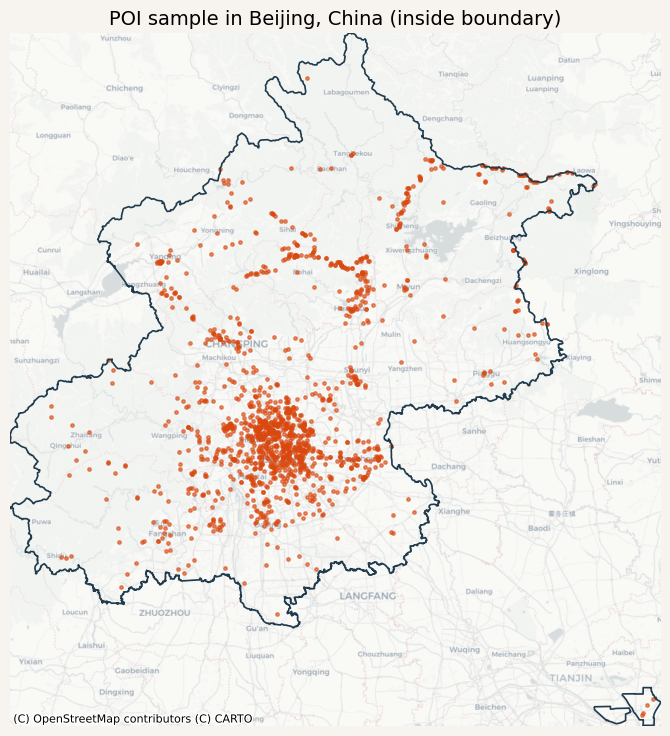

In [7]:
import matplotlib.pyplot as plt

try:
    import contextily as ctx
except ImportError:
    ctx = None
    print('contextily not installed; skipping basemap. Run: %pip install contextily')

# Sample points for a cleaner plot.
sample_n = 1500
sample_df = poi_df_filtered.sample(n=min(sample_n, len(poi_df_filtered)), random_state=7)
sample_gdf = gpd.GeoDataFrame(
    sample_df,
    geometry=gpd.points_from_xy(sample_df['lon'], sample_df['lat']),
    crs='EPSG:4326',
)

# Project to Web Mercator for basemap tiles.
sample_gdf_3857 = sample_gdf.to_crs(epsg=3857)
city_gdf_3857 = city_gdf.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(9, 9))
fig.patch.set_facecolor('#f7f3ee')
ax.set_facecolor('#f7f3ee')

minx, miny, maxx, maxy = city_gdf_3857.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

if ctx is not None:
    ctx.add_basemap(
        ax,
        source=ctx.providers.CartoDB.Positron,
        alpha=0.9,
    )

city_gdf_3857.boundary.plot(ax=ax, color='#1f3b4d', linewidth=1.2)
sample_gdf_3857.plot(ax=ax, color='#d9480f', markersize=6, alpha=0.6)

ax.set_title(f'POI sample in {city_name} (inside boundary)', fontsize=14)
ax.set_axis_off()
plt.show()


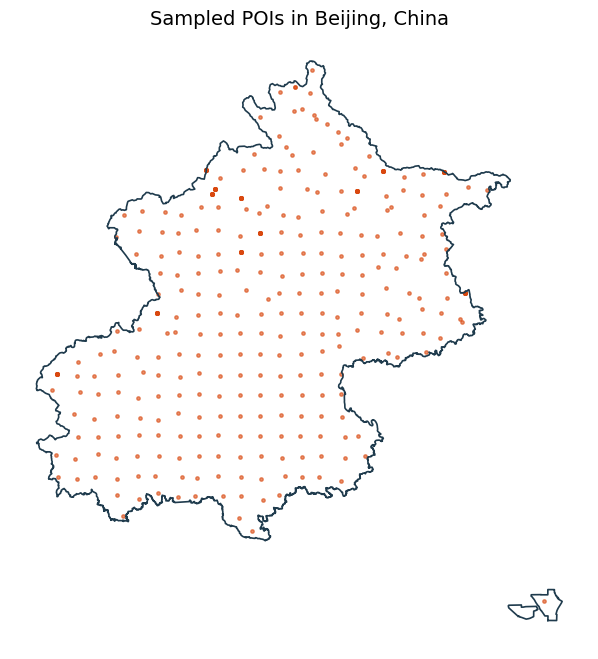

In [8]:
# Grid-based sampling (similar spirit to dataset_construction).
grid_step_m = 10000
max_points = 1500

poi_gdf = gpd.GeoDataFrame(
    poi_df_filtered,
    geometry=gpd.points_from_xy(poi_df_filtered['lon'], poi_df_filtered['lat']),
    crs='EPSG:4326',
).to_crs(epsg=3857)
poi_gdf = poi_gdf.reset_index(drop=True)

city_gdf_3857 = city_gdf.to_crs(epsg=3857)
city_geom_3857 = city_gdf_3857.geometry.iloc[0]

minx, miny, maxx, maxy = city_geom_3857.bounds
grid_points = [
    Point(x, y)
    for x in np.arange(minx, maxx, grid_step_m)
    for y in np.arange(miny, maxy, grid_step_m)
]
grid_gdf = gpd.GeoDataFrame(geometry=grid_points, crs='EPSG:3857')
grid_gdf = grid_gdf[grid_gdf.within(city_geom_3857)]

if grid_gdf.empty:
    print('Grid is empty; falling back to random sample.')
    sampled_poi_gdf = poi_gdf.sample(n=min(max_points, len(poi_gdf)), random_state=7)
else:
    try:
        joined = gpd.sjoin_nearest(
            grid_gdf,
            poi_gdf,
            how='left',
            distance_col='dist_m',
        )
        sampled_idx = joined['index_right'].dropna().drop_duplicates()
        sampled_poi_gdf = poi_gdf.loc[sampled_idx].copy()
    except Exception as exc:
        print(f'sjoin_nearest failed: {exc}; falling back to random sample.')
        sampled_poi_gdf = poi_gdf.sample(n=min(max_points, len(poi_gdf)), random_state=7)

if len(sampled_poi_gdf) > max_points:
    sampled_poi_gdf = sampled_poi_gdf.sample(n=max_points, random_state=7)

sampled_plot = sampled_poi_gdf.to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(8, 8))
city_gdf.boundary.plot(ax=ax, color='#1f3b4d', linewidth=1.2)
sampled_plot.plot(ax=ax, color='#d9480f', markersize=6, alpha=0.6)

ax.set_title(f'Sampled POIs in {city_name}', fontsize=14)
ax.set_axis_off()
plt.show()
